<a href="https://colab.research.google.com/github/Reaper-stack/AICTE_Major_project/blob/main/Seasonal_Agriculture_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [2]:

print("Missing values before cleaning:\n", df.isnull().sum())
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())
print("\nMissing values after cleaning:\n", df.isnull().sum())

Missing values before cleaning:
 Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3  

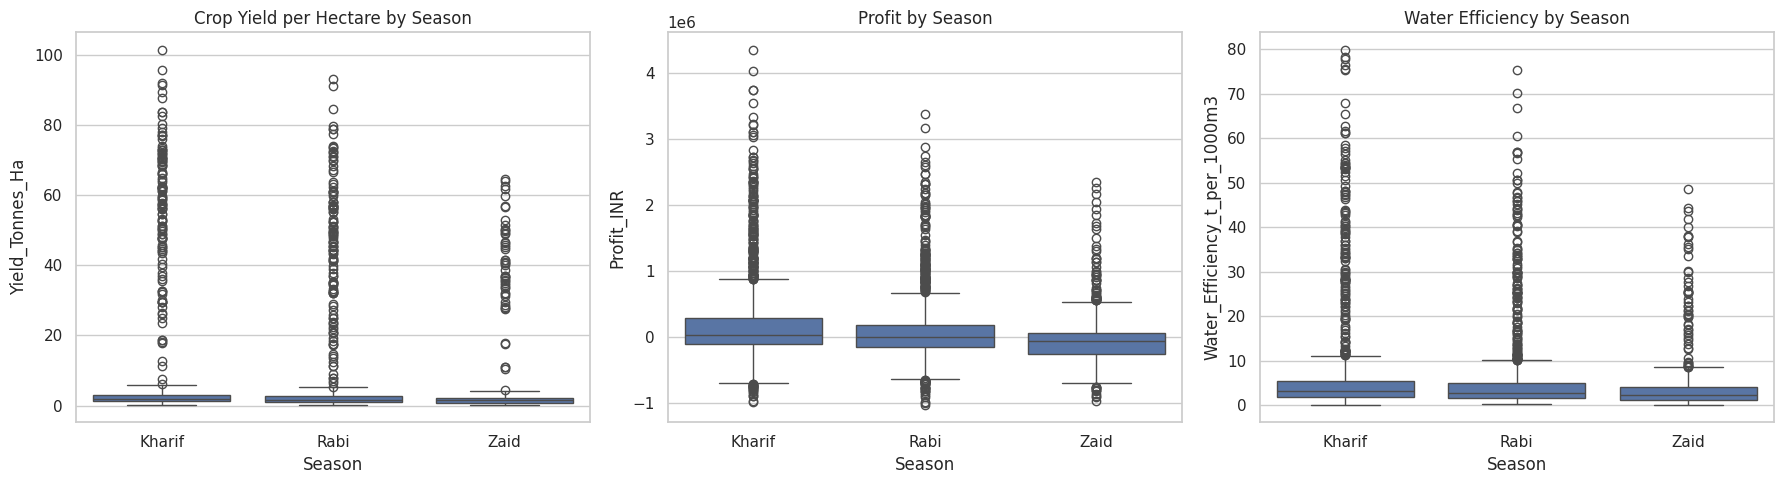

        Yield_Tonnes_Ha     Profit_INR
Season                                
Kharif         5.628612  178914.647555
Rabi           5.039435   87689.470191
Zaid           4.641313  -24804.824916


In [3]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0])
axes[0].set_title('Crop Yield per Hectare by Season')
sns.boxplot(data=df, x='Season', y='Profit_INR', ax=axes[1])
axes[1].set_title('Profit by Season')
sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', ax=axes[2])
axes[2].set_title('Water Efficiency by Season')
plt.tight_layout()
plt.show()
seasonal_stats = df.groupby('Season')[['Yield_Tonnes_Ha', 'Profit_INR']].mean()
print(seasonal_stats)

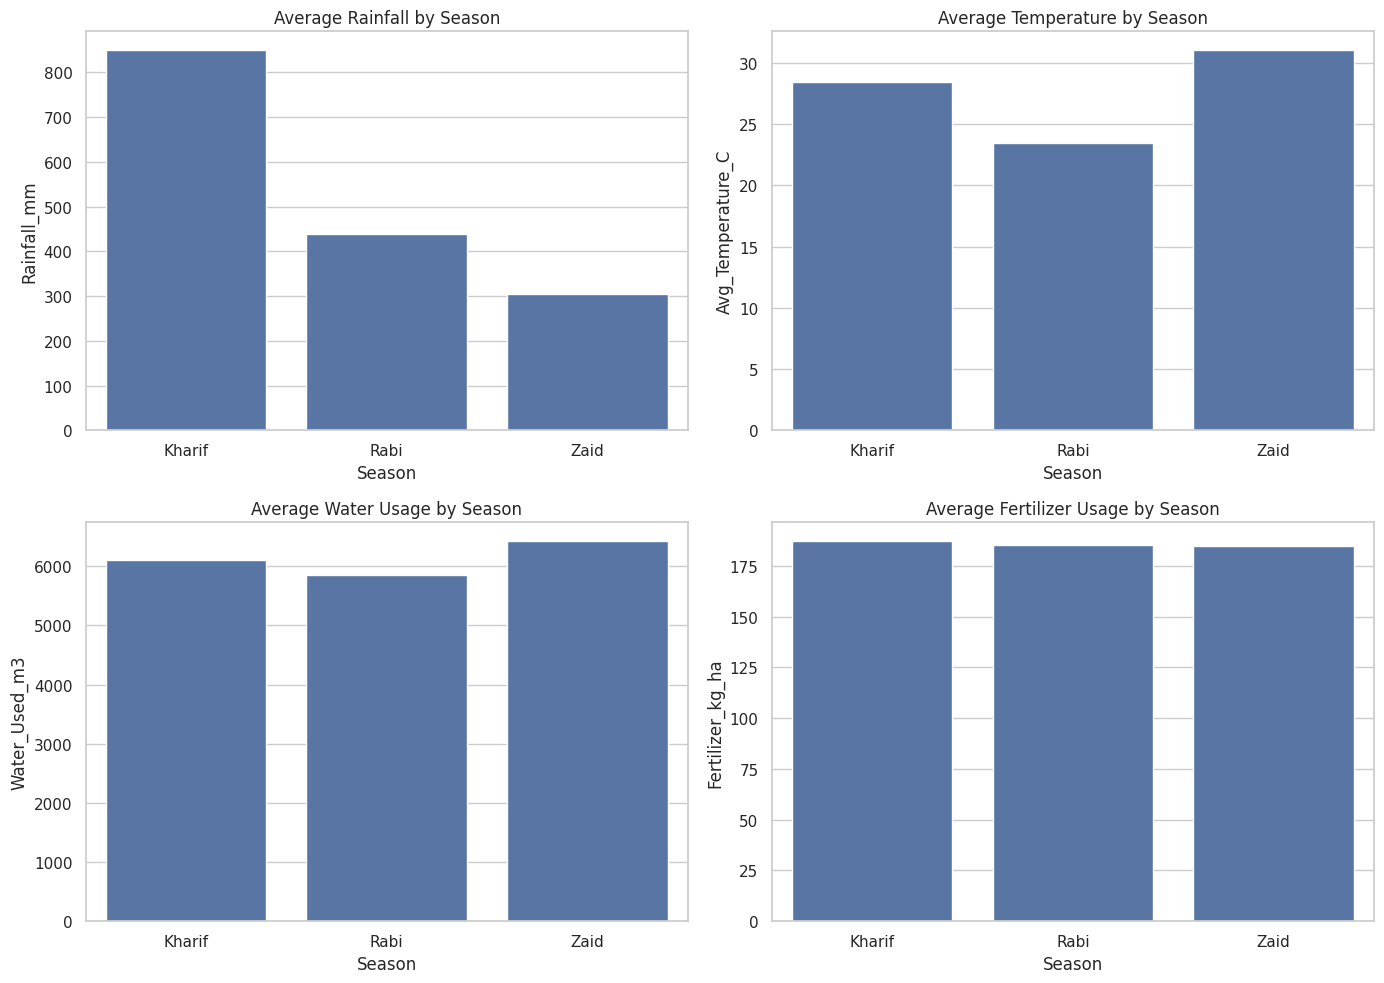

In [4]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=df, x='Season', y='Rainfall_mm', ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title('Average Rainfall by Season')

sns.barplot(data=df, x='Season', y='Avg_Temperature_C', ax=axes[0, 1], errorbar=None)
axes[0, 1].set_title('Average Temperature by Season')

sns.barplot(data=df, x='Season', y='Water_Used_m3', ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title('Average Water Usage by Season')

sns.barplot(data=df, x='Season', y='Fertilizer_kg_ha', ax=axes[1, 1], errorbar=None)
axes[1, 1].set_title('Average Fertilizer Usage by Season')

plt.tight_layout()
plt.show()

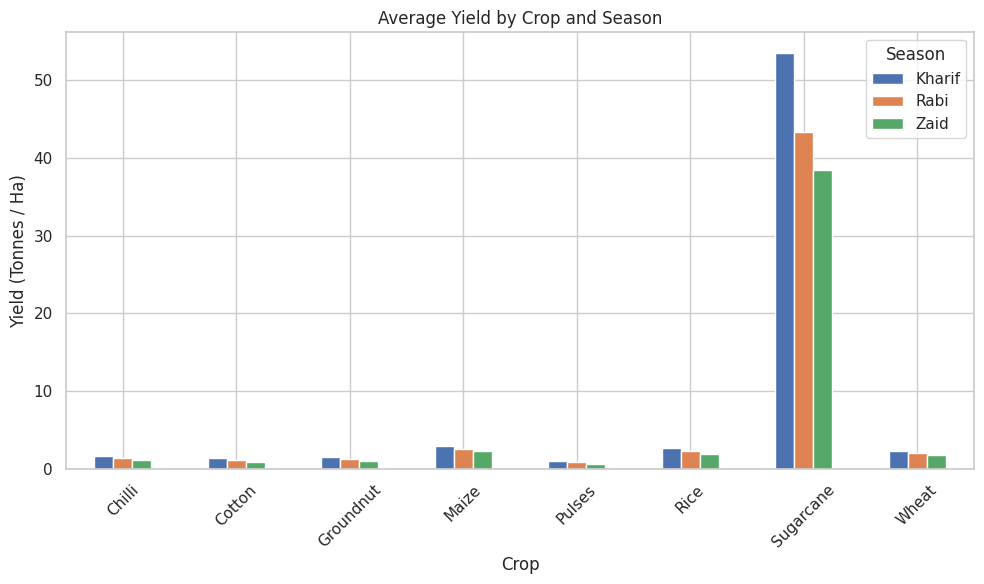

In [5]:

crop_season_yield = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().unstack()
crop_season_yield.plot(kind='bar', figsize=(10, 6))
plt.title('Average Yield by Crop and Season')
plt.ylabel('Yield (Tonnes / Ha)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')